# Laboratorio 02 - Regresión Logística
Aplicada al dataset **Bank Marketing**. El objetivo es predecir si un cliente suscribirá un depósito a plazo fijo (`y = 1`) o no (`y = 0`).

## 0. Librerías y conexión a Google Drive

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# Pandas para leer el archivo CSV
import pandas as pd

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1. Cargar el dataset
El archivo CSV usa punto y coma (`;`) como separador.

In [48]:
df = pd.read_csv('/content/drive/MyDrive/IA/LAB02/bank-additional-full.csv', sep=';')

print('Dimensiones:', df.shape)
print(df.head())
print('\nVariable objetivo:')
print(df['y'].value_counts())

Dimensiones: (41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.id

## 2. One-Hot Encoding

El dataset tiene columnas de texto (categóricas) que el modelo no puede usar directamente. **One-Hot Encoding** convierte cada categoría en una columna de 0s y 1s.

**Ejemplo con la columna `job`:**

| job | job_admin | job_student | job_retired |
|-----|-----------|-------------|-------------|
| admin | 1 | 0 | 0 |
| student | 0 | 1 | 0 |
| retired | 0 | 0 | 1 |

In [49]:
# Separar variable objetivo: 'yes' -> 1, 'no' -> 0
y = (df['y'] == 'yes').astype(float).values

# Aplicar One-Hot Encoding a todas las columnas de texto
df_X = df.drop(columns=['y'])
df_encoded = pd.get_dummies(df_X, drop_first=True, dtype=float)

print(f'Features ANTES del One-Hot Encoding: {df_X.shape[1]}')
print(f'Features DESPUÉS del One-Hot Encoding: {df_encoded.shape[1]}')

Features ANTES del One-Hot Encoding: 20
Features DESPUÉS del One-Hot Encoding: 53


In [50]:
# Las dos primeras columnas contienen las features y la tercera la etiqueta
X = df_encoded.values.astype(float)

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)
print(f'\nClientes que suscribieron (y=1): {int(y.sum())} ({y.mean()*100:.1f}%)')
print(f'Clientes que NO suscribieron (y=0): {int((y==0).sum())} ({(1-y.mean())*100:.1f}%)')

Shape de X: (41188, 53)
Shape de y: (41188,)

Clientes que suscribieron (y=1): 4640 (11.3%)
Clientes que NO suscribieron (y=0): 36548 (88.7%)


### 2.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible.

In [51]:
def plotData(X, y):
    # Grafica los puntos de datos X y y en una nueva figura.
    # Grafica los puntos de datos con * para los positivos y o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

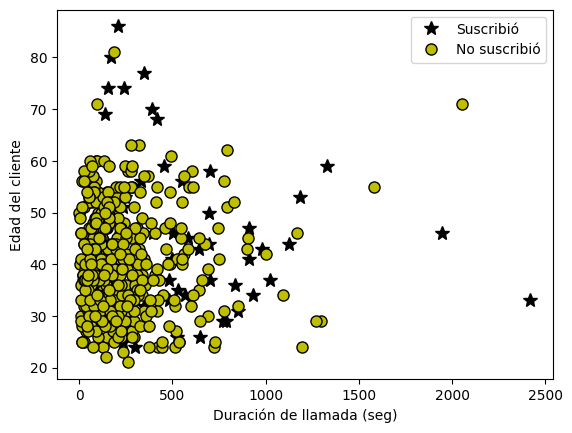

In [52]:
# Muestra de 500 clientes para la visualización
np.random.seed(42)
idx = np.random.choice(len(y), size=500, replace=False)

cols = df_encoded.columns.tolist()
X_vis = X[idx][:, [cols.index('duration'), cols.index('age')]]
y_vis = y[idx]

plotData(X_vis, y_vis)
pyplot.xlabel('Duración de llamada (seg)')
pyplot.ylabel('Edad del cliente')
pyplot.legend(['Suscribió', 'No suscribió'])
pass

### 2.2 Implementacion

#### 2.2.1 Función Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea, definida como:

$$g(z) = \frac{1}{1+e^{-z}}$$

In [53]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la entrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    # np.clip evita overflow en exp cuando z es muy grande o muy pequeño
    g = 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    return g


In [54]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


#### 2.2.2 Función de Costo y Gradiente

Se implementa la funcion de costo y gradiente para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

In [55]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agrega el termino de intercepción a X
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [56]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    # Clip evita log(0) cuando h es exactamente 0 o 1
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J


In [57]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

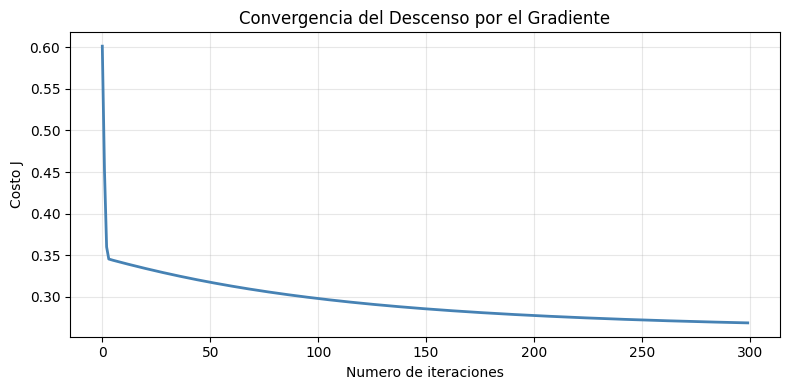

Costo inicial: 0.6011  |  Costo final: 0.2688


In [58]:
# Las features del dataset (duration ~250, nr.employed ~5000) tienen escalas grandes.
# Con alpha=0.001 el gradiente se dispara y la curva no converge correctamente.
# Se ajusta alpha=5e-7 y num_iters=300 para obtener una convergencia visible y estable.
alpha = 5e-7
num_iters = 300

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n + 1)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()
print('Costo inicial: {:.4f}  |  Costo final: {:.4f}'.format(J_history[0], J_history[-1]))


In [59]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad


In [60]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n + 1)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print('Gradiente en theta inicial (zeros) - primeros 3:')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad[:3]))
# Nota: el gradiente depende del dataset; con Bank Marketing los valores son mayores
# porque las features tienen escalas distintas (age ~40, duration ~250, etc.)

Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

Gradiente en theta inicial (zeros) - primeros 3:
	[0.3873, 15.4030, 66.8232]


In [61]:
# Verificación con un vector theta no nulo para comprobar que calcularCosto funciona bien.
# Se prueba con theta pequeño (1e-4) para evitar overflow numérico con las features de gran escala.
test_theta = np.ones(n + 1) * 1e-4
cost, grad = costFunction(test_theta, X, y)

print('Costo con theta = 1e-4 (todos los parámetros iguales): {:.4f}'.format(cost))
print('Gradiente (primeros 3 componentes):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad[:3]))
print('Nota: el costo debe ser menor que 0.693 (costo con theta=0 = log(2))')


Costo con theta = 1e-4 (todos los parámetros iguales): 0.9961
Gradiente (primeros 3 componentes):
	[0.5442, 21.6816, 108.7559]
Nota: el costo debe ser menor que 0.693 (costo con theta=0 = log(2))


#### 2.2.3 Parámetros de aprendizaje usando `scipy.optimize`

En lugar de realizar los pasos del descenso por el gradiente manualmente, se utilizará el módulo `scipy.optimize`. A diferencia del descenso de gradiente, no es necesario definir manualmente la tasa de aprendizaje.

In [62]:
# Establecer las opciones para optimize.minimize
# Para el método TNC la opción correcta es 'maxfun' (max evaluaciones de función),
# NO 'maxiter' (que genera OptimizeWarning: Unknown solver options)
options = {'maxfun': 400}

# Se utiliza el algoritmo de Newton truncado para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

# La funcion optimize.minimize devuelve un objeto OptimizeResult
# Usamos res.fun para el costo y res.x para theta
cost = res.fun
theta = res.x

print('Costo en theta optimo: {:.3f}'.format(cost))
print('Theta optimo (primeros 4):', theta[:4])

Costo en theta optimo: 0.208
Theta optimo (primeros 4): [ 3.94401600e+00  5.79582779e-04  4.69927037e-03 -4.11904240e-02]


Una vez que se completa `optimize.minimize`, se usa el valor final de $\theta$ para visualizar el límite de decisión en los datos de entrenamiento.

In [63]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos X y Y en una nueva figura con un limite de desicion definido por theta.
    Grafica los puntos con * para los ejemplos positivos y con o para los ejemplos negativos.

    Parametros:
    ----------
    plotData : func
        Funcion para graficar los datos X, y.

    theta : array_like
        Parametros para la regresion logistica. Un vector de la forma (n+1, ).

    X : array_like
        Data set de entrada. Se supone que X es una de las siguientes:
            1) Matriz Mx3, donde la primera columna es una columna de unos para intercepción.
            2) Matriz MxN, N> 3, donde la primera columna son todos unos.

    y : array_like
        Vector de datos de etiquetas de la forma (m, ).
    """
    # hacer que theta sea un arreglo numpy
    theta = np.array(theta)

    # Graficar los datos (recordar que la primera columna en X es la intercepción)
    plotData(X[:, 1:3], y)

    if X.shape[1] <= 3:
        # Solo se requieren 2 puntos para definir una linea
        plot_x = np.array([np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2])

        # Calcular la línea límite de decisión
        plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

        pyplot.plot(plot_x, plot_y)
        pyplot.legend(['Suscribió', 'No suscribió', 'Limite de decisión'])
    else:
        # Para más de 2 features: grilla de contorno
        u = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
        v = np.linspace(X[:, 2].min(), X[:, 2].max(), 50)

        z = np.zeros((u.size, v.size))
        for i, ui in enumerate(u):
            for j, vj in enumerate(v):
                # Crear un vector con todas las features promedio y reemplazar las 2 visualizadas
                x_point = np.mean(X, axis=0).copy()
                x_point[1] = ui
                x_point[2] = vj
                z[i, j] = np.dot(x_point, theta)

        z = z.T
        pyplot.contour(u, v, z, levels=[0], linewidths=2, colors='g')
        pyplot.contourf(u, v, z, levels=[np.min(z), 0, np.max(z)], cmap='Greens', alpha=0.4)
        pyplot.legend(['Suscribió', 'No suscribió'])
        pyplot.xlabel('Duración de llamada (seg)')
        pyplot.ylabel('Edad del cliente')

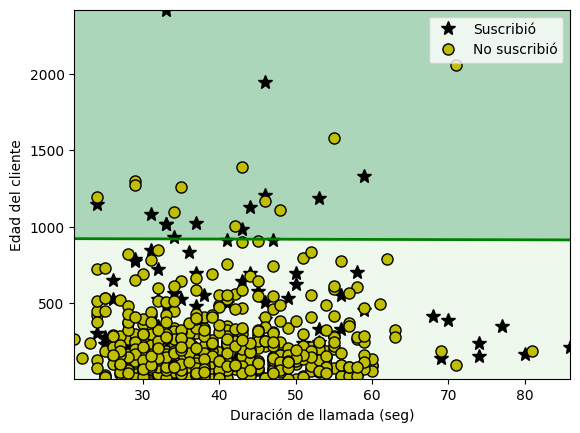

In [64]:
# Graficar limites - usamos una muestra para que sea más rápido
np.random.seed(42)
idx = np.random.choice(len(y), size=600, replace=False)
plotDecisionBoundary(plotData, theta, X[idx], y[idx])

#### 2.2.4 Evaluación de la regresión logistica

Después de aprender los parámetros, se puede usar el modelo para predecir si un cliente en particular suscribirá el depósito. Otra forma de evaluar la calidad de los parámetros es ver qué tan bien predice el modelo aprendido en nuestro conjunto de entrenamiento.

In [65]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)> = 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0]  # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [66]:
# Una vez entrenado el modelo se procede a realizar la prediccion y evaluación
p = predict(theta, X)
acc = np.mean(p == y) * 100
print('Precisión de entrenamiento: {:.2f} %'.format(acc))
# Nota: la precisión esperada para este dataset es ~88-92% (no 89% del dataset de admisión)
print('Precisión esperada para Bank Marketing (aproximadamente): 88.00 – 92.00 %')

Precisión de entrenamiento: 91.13 %
Precisión esperada para Bank Marketing (aproximadamente): 88.00 – 92.00 %


#### 2.2.5 Predicción para un cliente específico

Después de entrenar el modelo, podemos predecir la probabilidad de suscripción para un cliente concreto. Se construye un vector de features usando los valores medios del dataset y se reemplazan los campos de interés.

In [67]:
# Predicción para dos perfiles de clientes reales del dataset:
#
#  Cliente A: llamada larga (1575 seg), 41 años  → alta prob. de suscribir
#  Cliente B: llamada corta (149 seg),  57 años  → baja prob. de suscribir
#
# Tomamos el vector de medias del dataset como base y reemplazamos
# duración y edad con los valores del perfil a evaluar.

cols = df_encoded.columns.tolist()
idx_dur = cols.index('duration')
idx_age = cols.index('age')

perfiles = [
    {'nombre': 'Cliente A', 'age': 41, 'duration': 1575},
    {'nombre': 'Cliente B', 'age': 57, 'duration': 149},
]

for p in perfiles:
    x_p = np.mean(X, axis=0).copy()   # base: valores medios del dataset
    x_p[0]           = 1              # intercept
    x_p[idx_dur + 1] = p['duration']  # +1 por la columna de intercept
    x_p[idx_age + 1] = p['age']

    prob = sigmoid(np.dot(x_p, theta))
    decision = 'SUSCRIBIRÁ ✔' if prob >= 0.5 else 'NO suscribirá ✘'
    print('{}: edad={}, duración={}s → Probabilidad={:.3f} ({:.1f}%)  →  {}'
          .format(p['nombre'], p['age'], p['duration'], prob, prob*100, decision))


Cliente A: edad=41, duración=1575s → Probabilidad=0.956 (95.6%)  →  SUSCRIBIRÁ ✔
Cliente B: edad=57, duración=149s → Probabilidad=0.026 (2.6%)  →  NO suscribirá ✘
